# Financial Network Analysis — Portfolio Insights

## Project Overview
This project builds a market-neutral trading strategy derived purely from the
topology of a financial correlation network. No price momentum, no fundamental
data, no parameter optimization — only the structural position of each stock
within the network.

**Universe:** ~50 S&P 500 stocks + 5 crypto assets  
**Period:** 2019–2024  
**Frequency:** Weekly rebalancing

## 1. Correlation Structure

The heatmap reveals two distinct worlds within our universe. The equity block 
shows moderate positive correlations throughout — most S&P 500 stocks move 
together to some degree, reflecting shared exposure to macro conditions. 
The crypto cluster (BTC, ETH, BNB, SOL, XRP) sits in its own corner with 
near-zero correlation to equities, confirming they operate in a completely 
separate risk regime. This immediately justifies excluding crypto from the 
long/short signal — they would introduce a different and unrelated source of 
risk into the strategy.

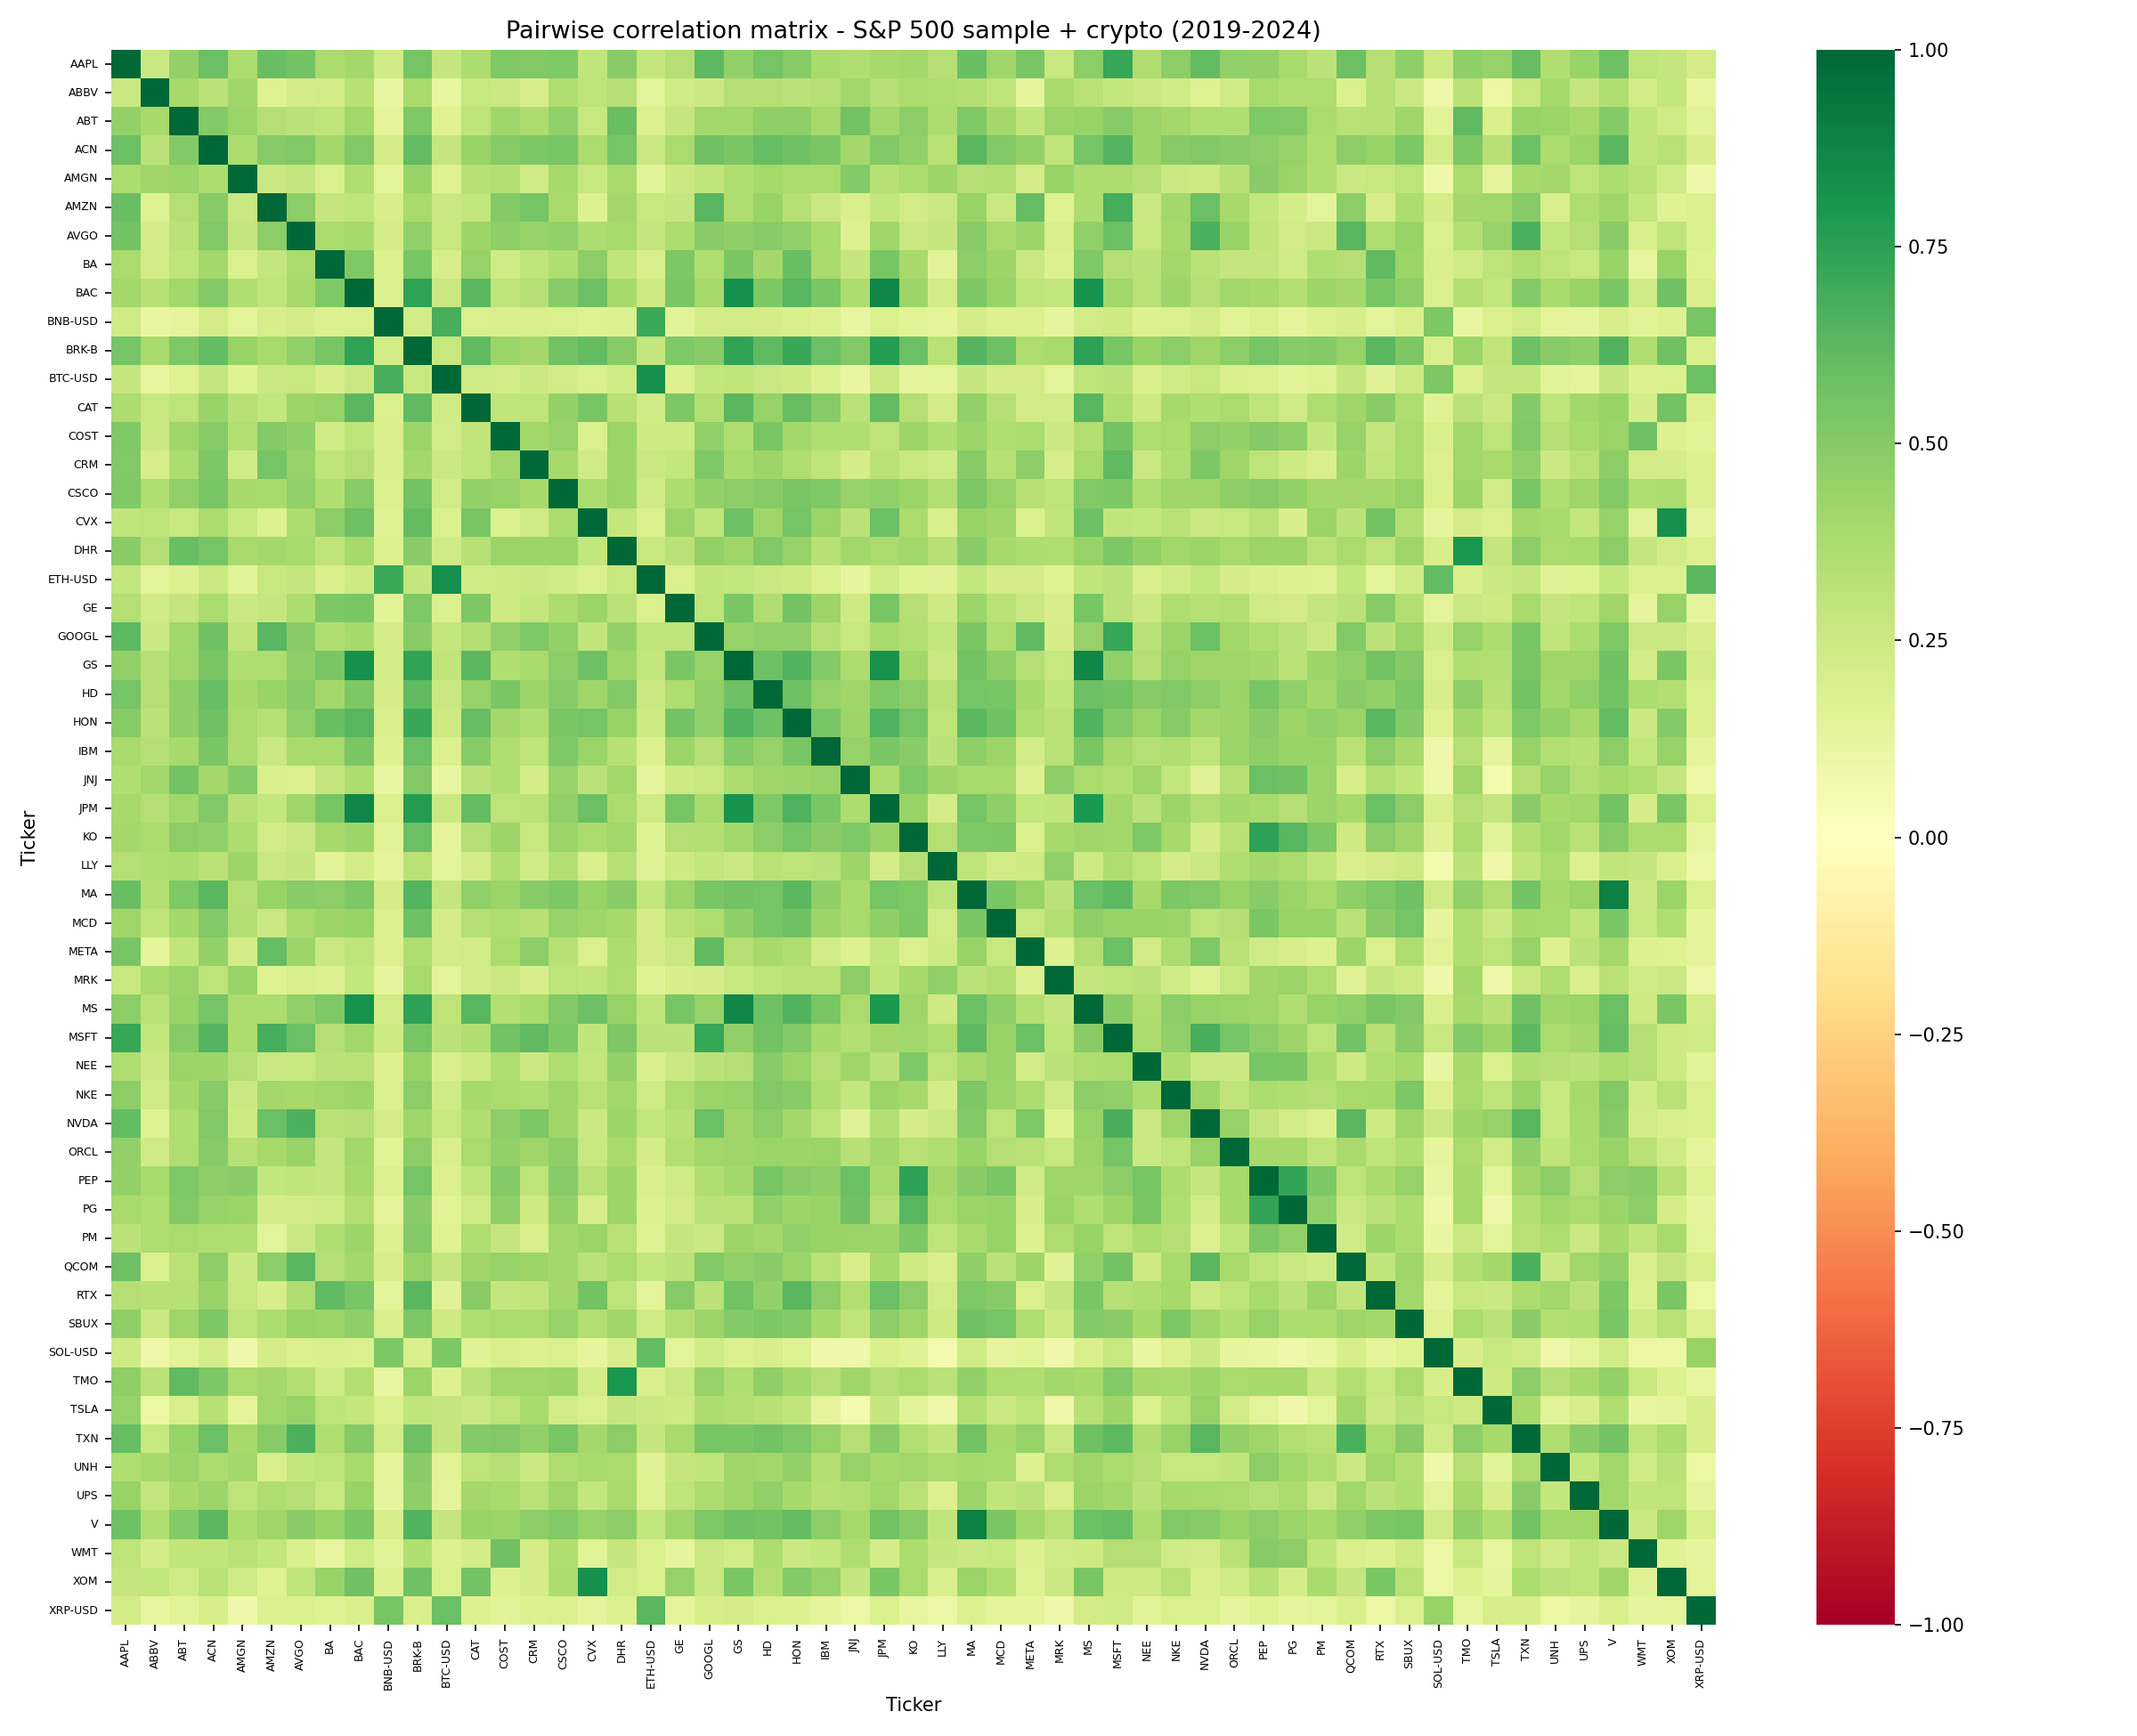

In [1]:
from IPython.display import Image, display
display(Image("correlation_matrix.png"))

## 2. Network Construction

Thresholding the correlation matrix at 0.4 produces a sparse graph that 
preserves only meaningful relationships. The result is telling: most equities 
form one dense central cluster, while peripheral stocks like MRK, UPS, TSLA, 
LLY, and UNH sit isolated at the edges with few or no connections. Crypto 
forms a completely separate island in the bottom-left — connected internally 
but disconnected from the equity universe. This separation will drive the 
signal construction.

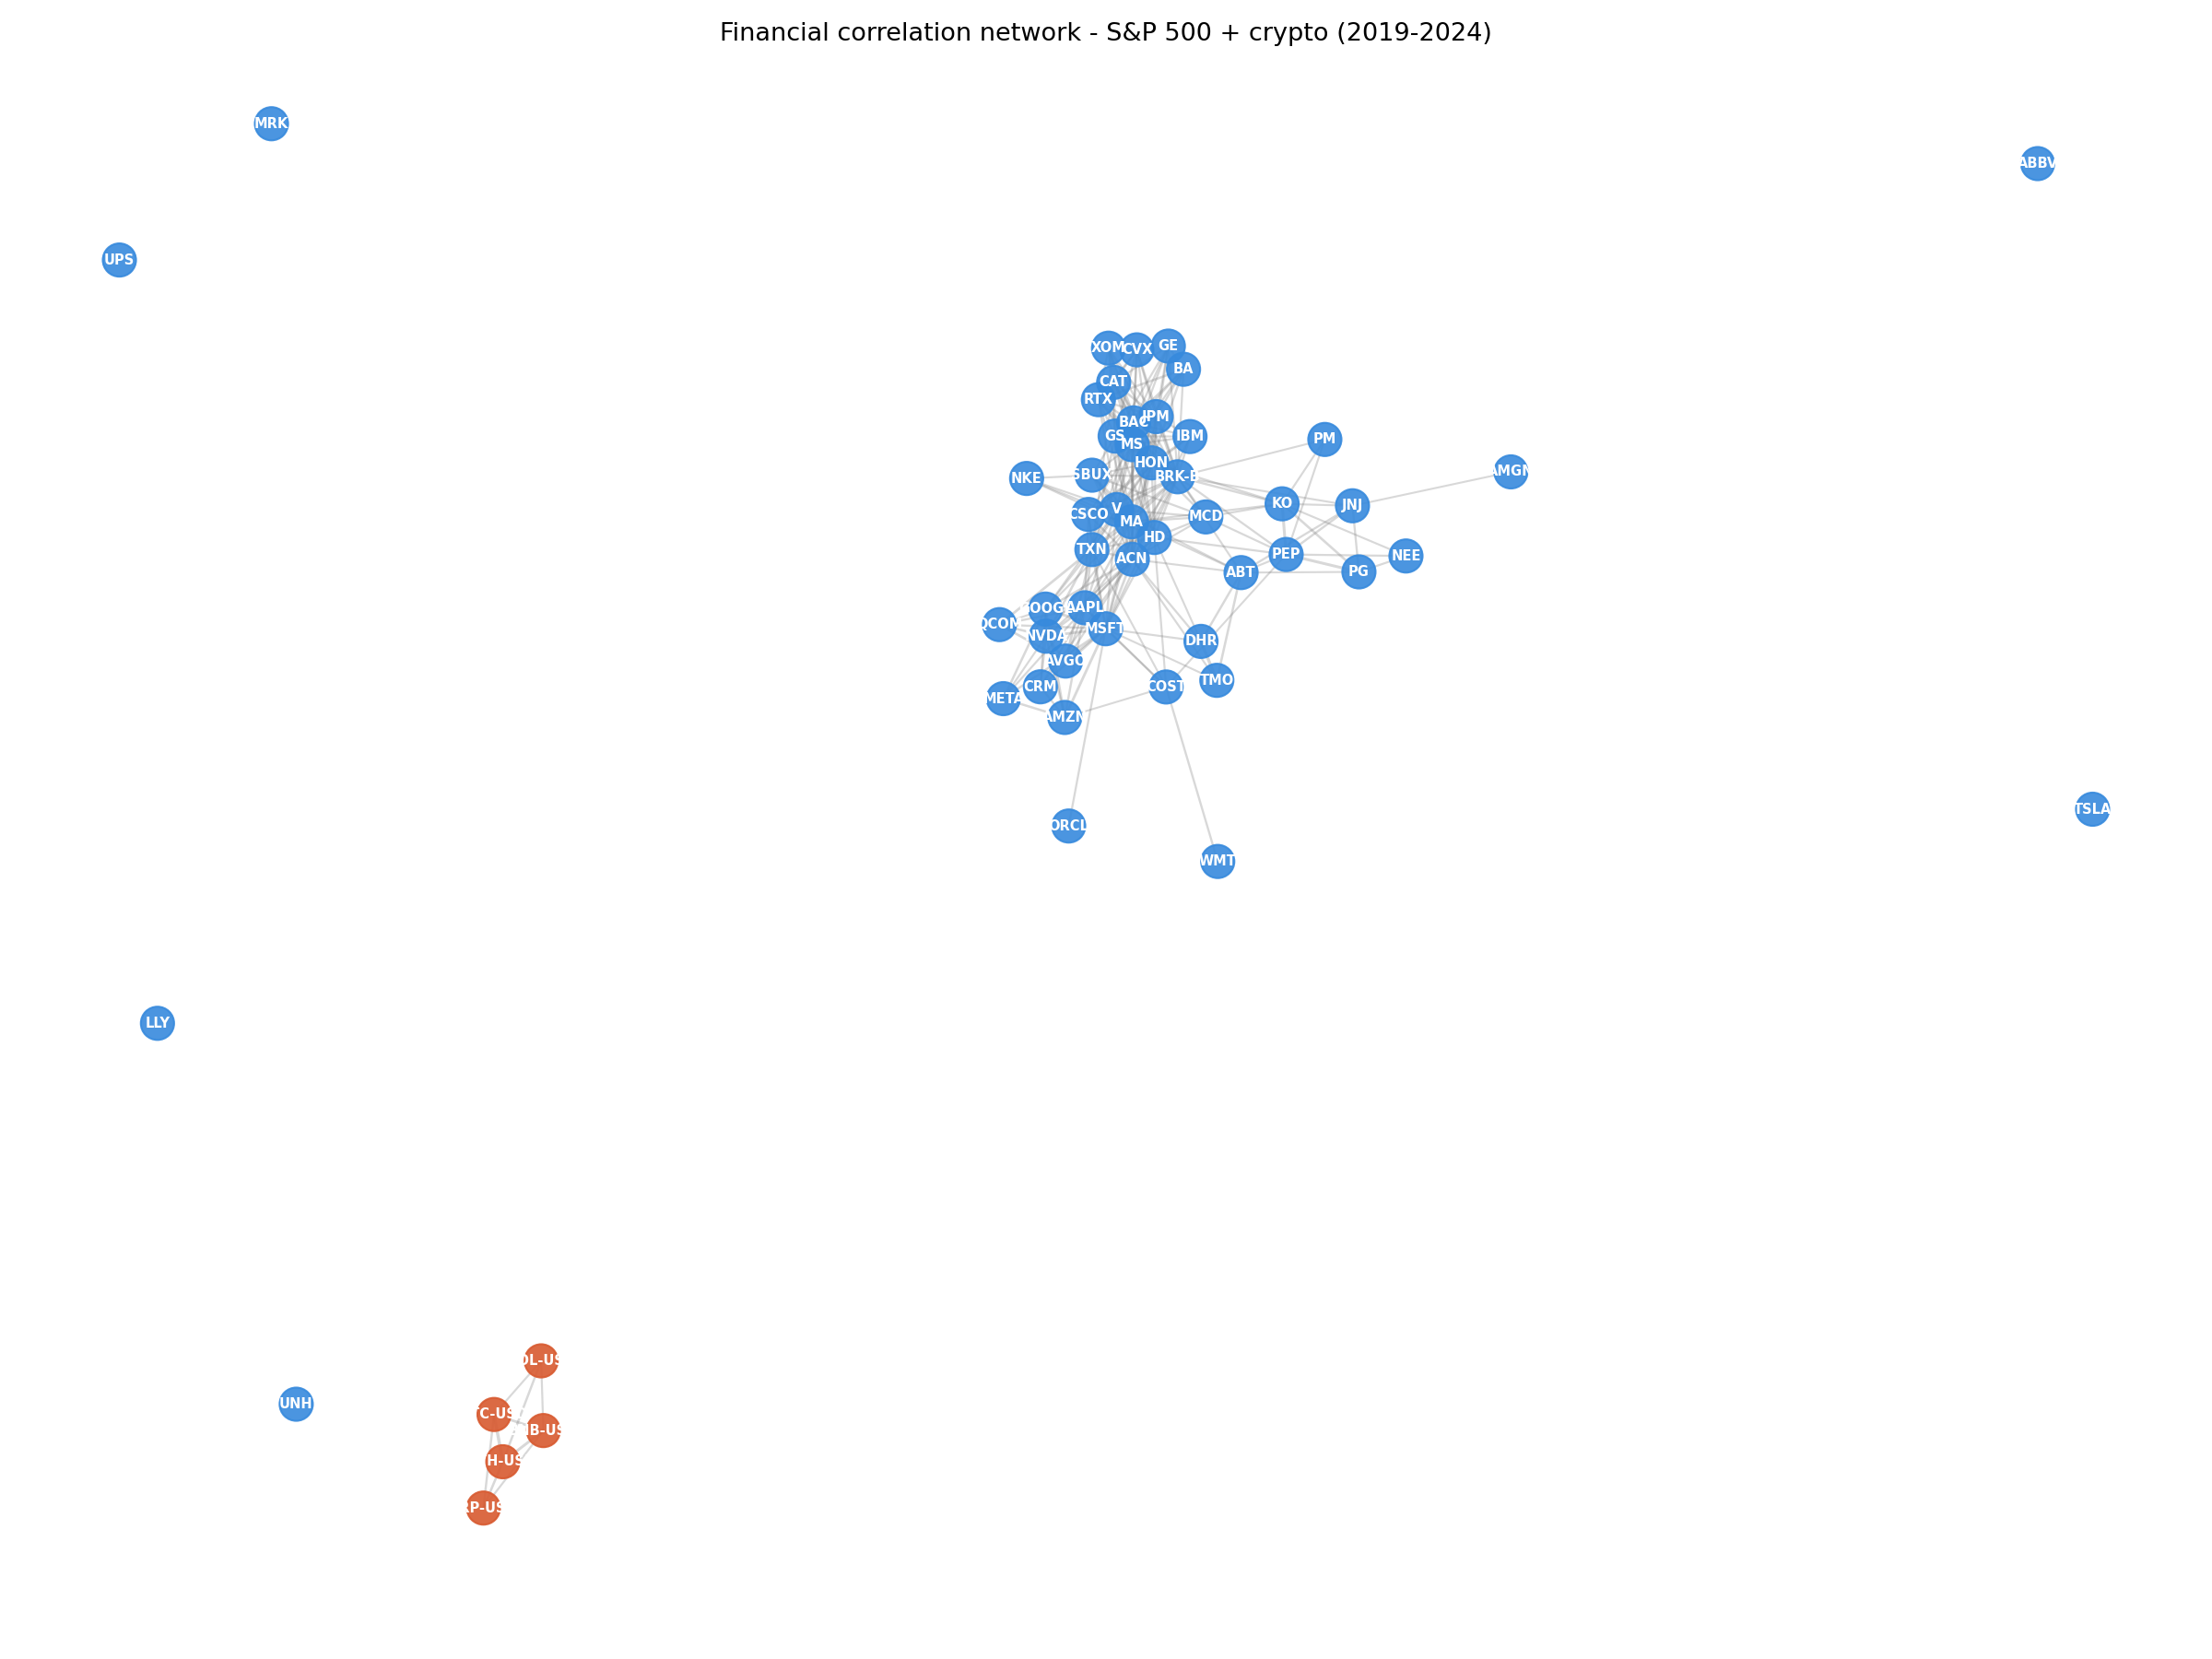

In [2]:
display(Image("network_graph.png"))

## 3. Community Detection

The Louvain algorithm, applied without any sector labels, recovers structure 
that closely mirrors real market sectors. It identifies:
- **Tech & Growth** (blue): AAPL, MSFT, NVDA, META, AMZN, GOOGL — the 
  growth cluster
- **Industrials & Finance** (orange/red): BRK-B, ACN, GS, MS, JPM, BAC, 
  CAT, RTX — the economy-sensitive cluster
- **Defensives** (green): JNJ, PEP, KO, NEE, AMGN — low-beta, stable stocks
- **Consumer** (yellow): MCD, HD, COST, SBUX
- **Crypto** (purple): isolated, as expected
- **Isolated** (gray): MRK, UPS, TSLA, LLY — stocks with idiosyncratic 
  behavior, weakly connected to any group

The fact that the algorithm recovers sector structure purely from return 
correlations — without ever seeing a sector label — validates the network 
approach as a meaningful representation of market structure.

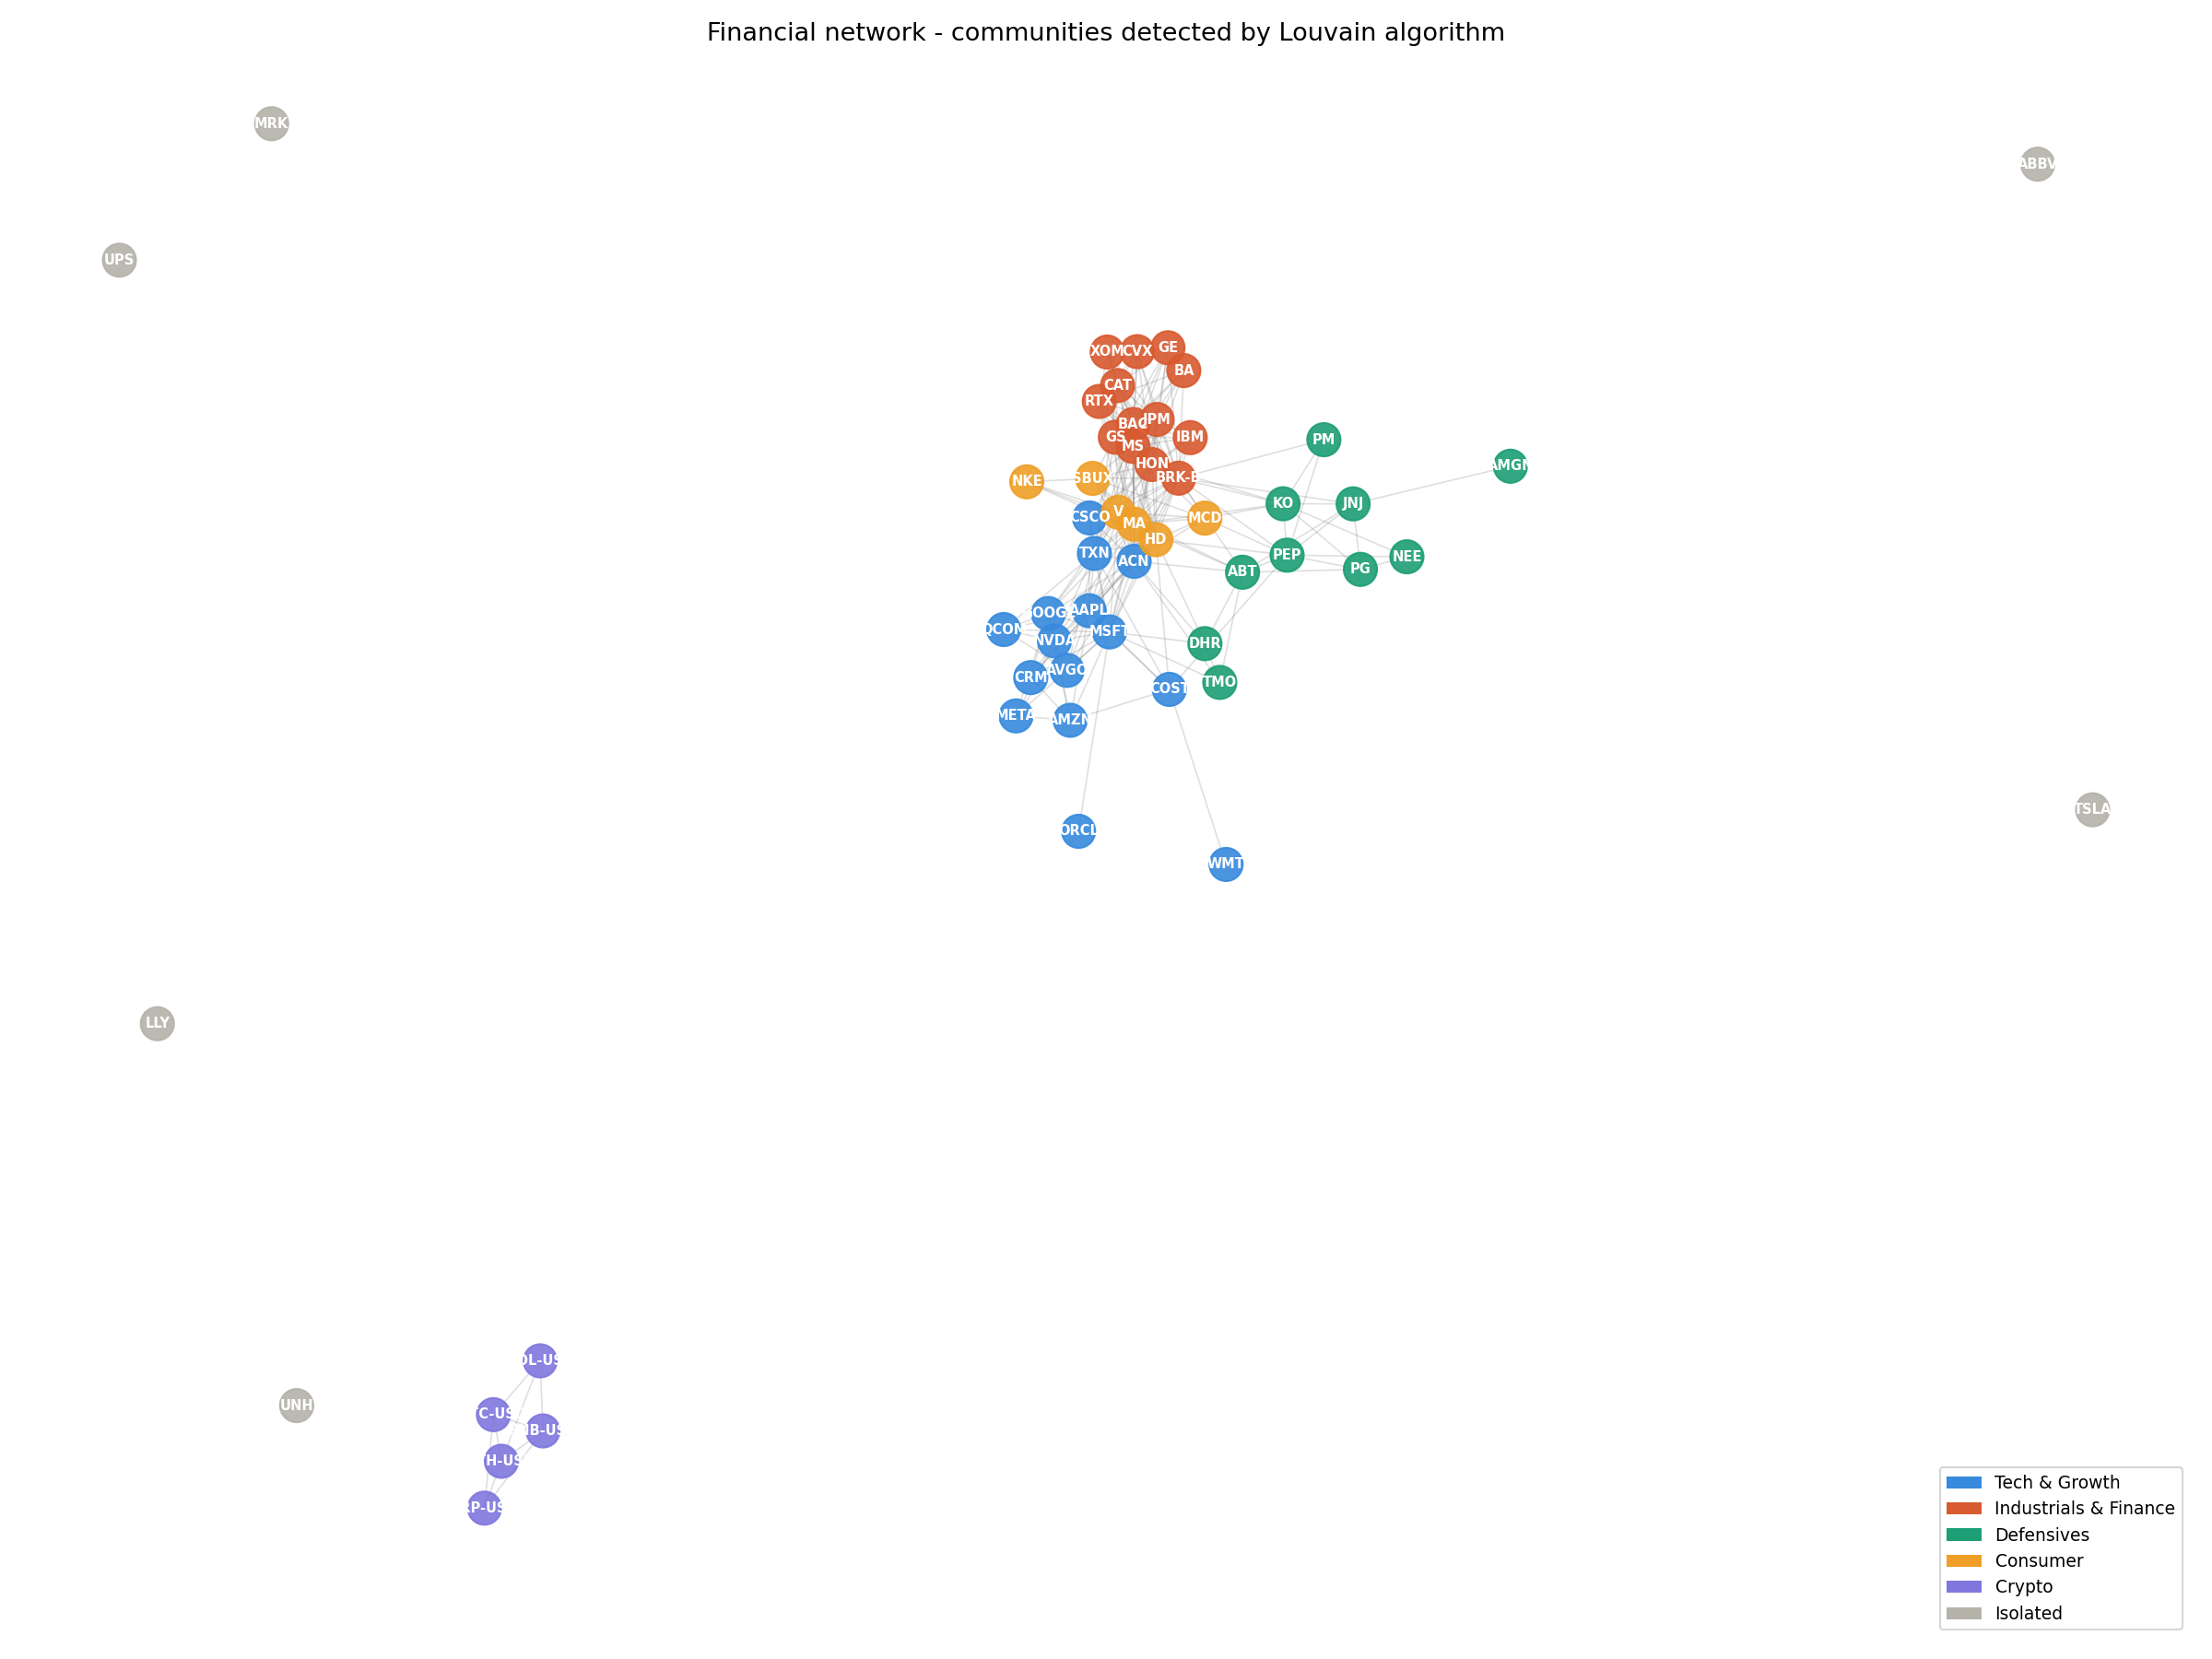

In [3]:
display(Image("community_network.png"))

## 4. Centrality Measures

Three centrality measures paint a consistent picture of who the market hubs are:

- **BRK-B and ACN dominate betweenness centrality** — they sit on the most 
  shortest paths between other stocks. BRK-B makes sense: it's a conglomerate 
  holding positions across every sector. ACN (Accenture) serves clients across 
  all industries, making it a natural bridge between tech and industrial stocks.
- **Degree centrality** confirms BRK-B and ACN as the most connected nodes — 
  directly correlated with the largest number of other stocks.
- **Eigenvector centrality** (which measures connection to other well-connected 
  stocks) shows a broader set of financials dominating: BRK-B, HON, MS, GS, MA.

These hub stocks — the ones we short — are precisely the stocks that are most 
exposed to systemic contagion. When the market dislocates, these are the first 
to transmit and amplify the shock.

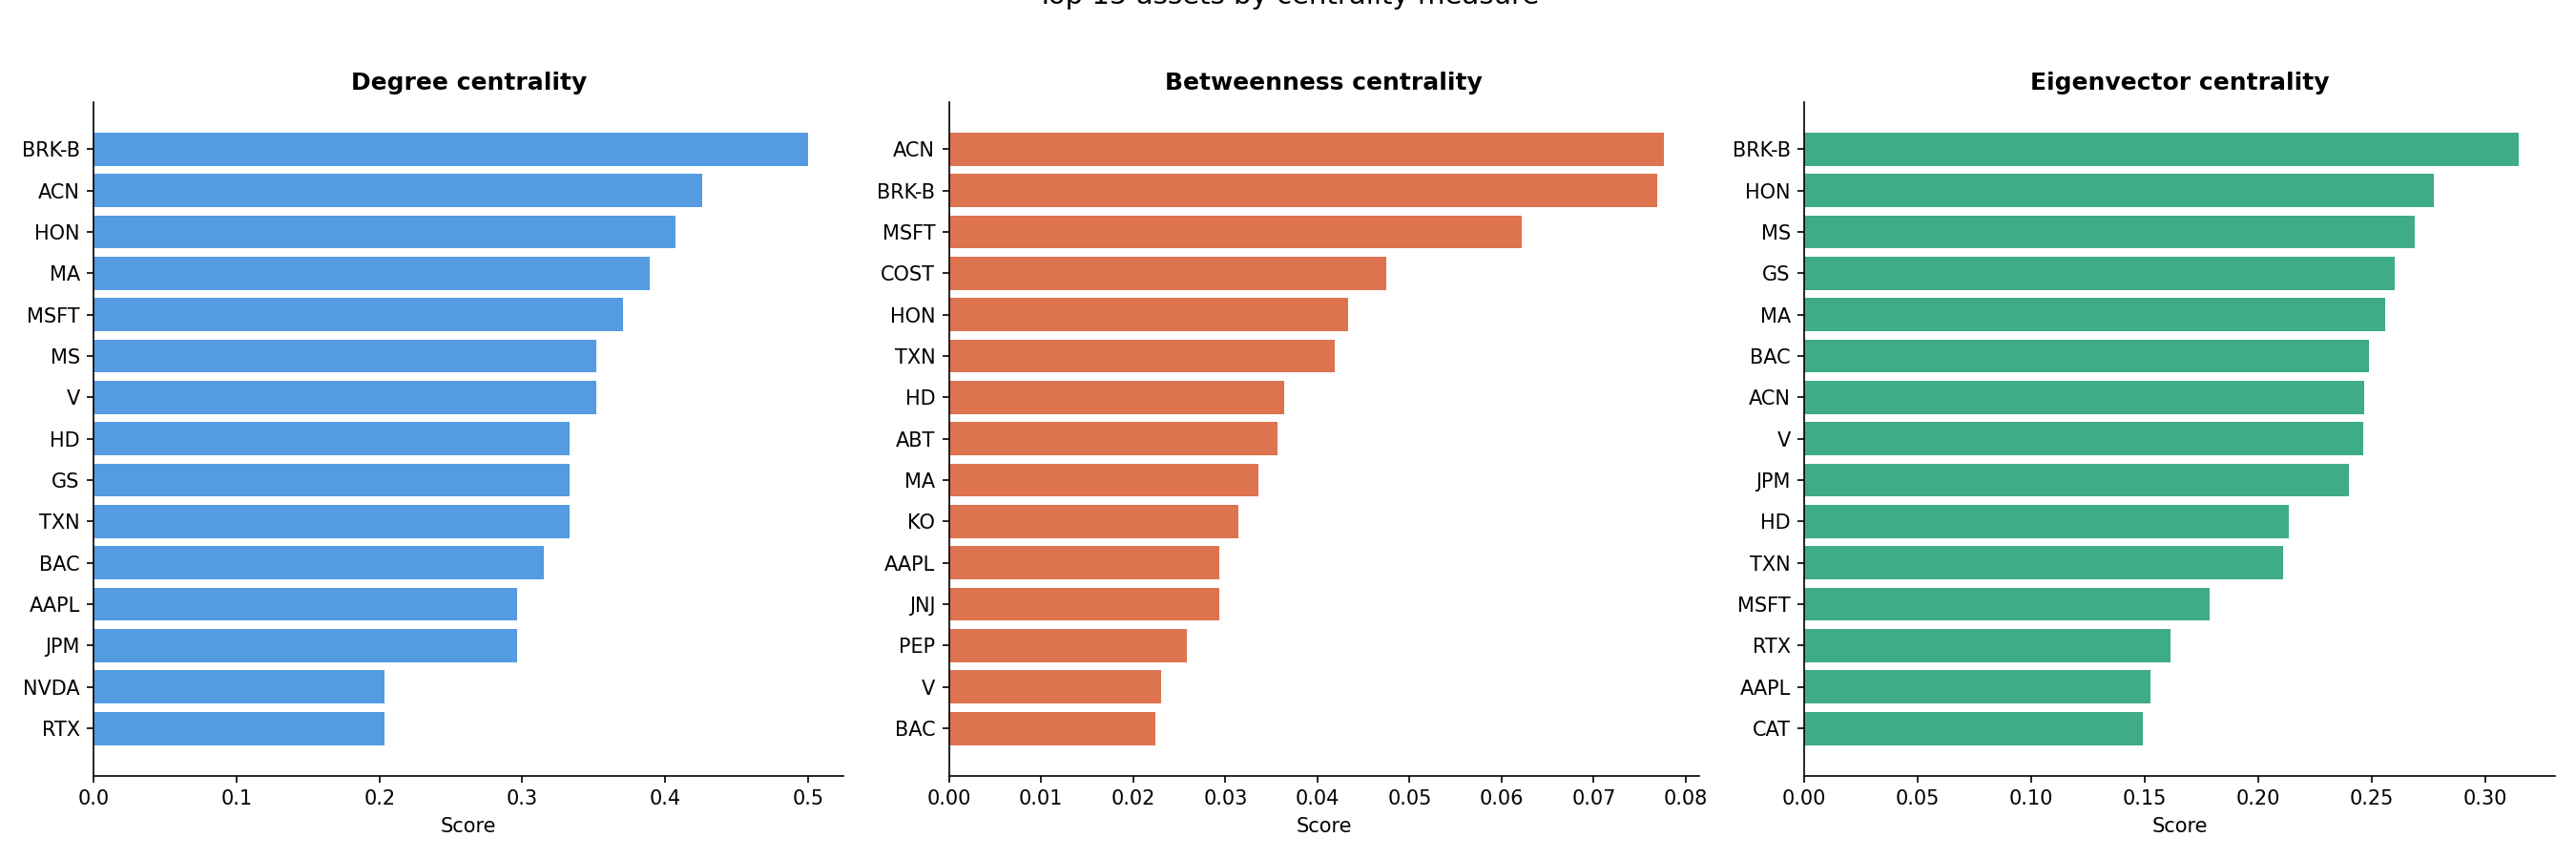

In [4]:
display(Image("centrality_measure.png"))

## 5. Network Dynamics — Rolling Density

Network density measures the fraction of all possible edges that actually exist 
at a given moment. A denser network means more stocks are moving together — 
a sign of stress and systemic risk.

Two spikes stand out clearly:
- **COVID crash (early 2020)**: density briefly hits 0.9 — nearly every stock 
  in the universe becomes correlated with every other. This is panic: all 
  distinctions between sectors collapse, everything sells off together.
- **2022 rate hike period**: a more sustained elevation of density, reflecting 
  a prolonged regime shift as rising rates repriced the entire equity universe 
  simultaneously.

In calm periods (2019, 2023–2024) density stays below 0.2 — the network is 
sparse and stocks behave more independently. This dynamic is exactly what 
the strategy exploits: in high-density regimes, hub stocks get hit hardest.

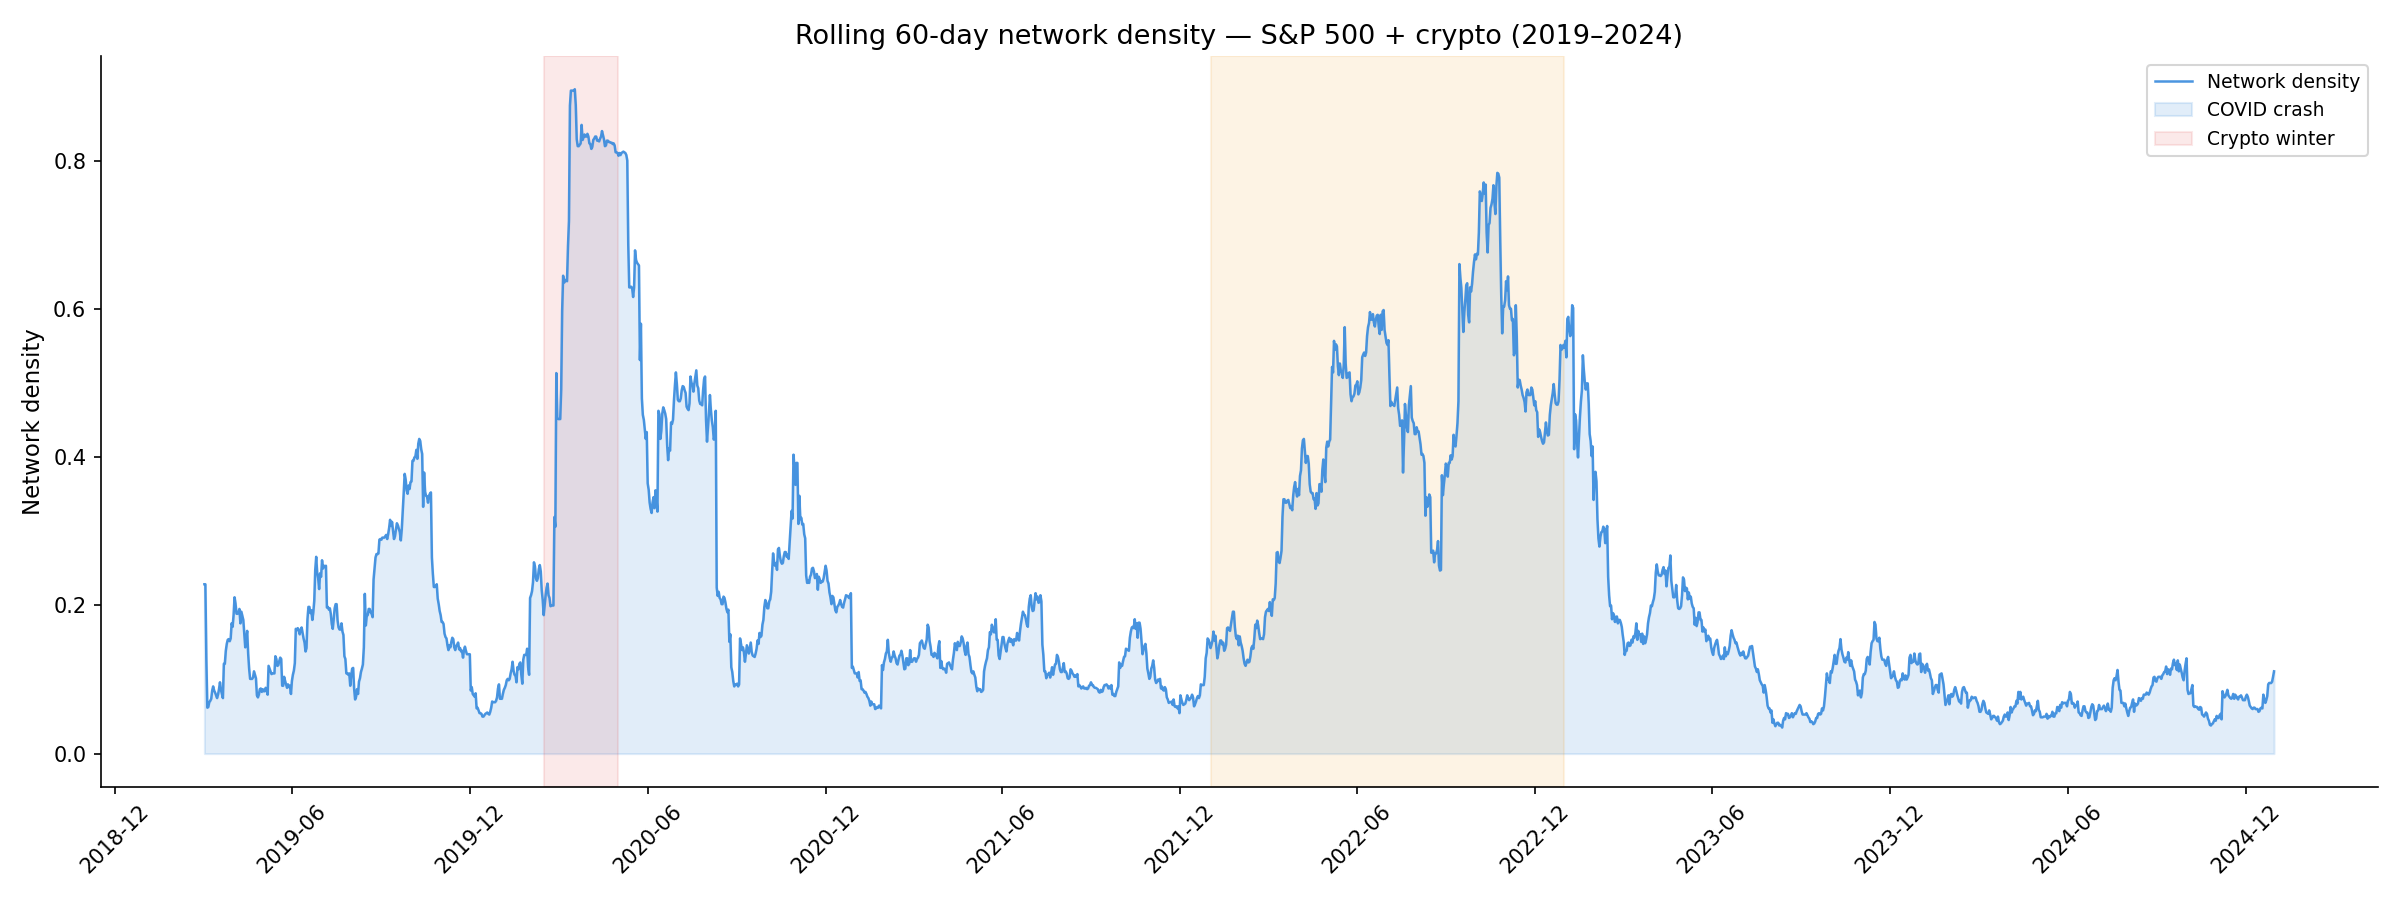

In [5]:
display(Image("rolling_density.png"))

## 6. Crisis Network Behavior

Comparing the network across four regimes reveals how dramatically structure 
changes with market conditions:

- **Calm (2019, 148 edges)**: a loose cluster with many isolated peripheral 
  nodes. The market is functioning normally, stocks trade on their own fundamentals.
- **Full period average (242 edges)**: denser, but still structured with 
  clear communities.
- **Crypto winter (2022, 540 edges)**: a dramatic increase — nearly 4x the 
  calm period. The entire equity universe tightens as rate hikes create a 
  uniform headwind across all sectors.
- **COVID crash (2020, 1087 edges)**: extreme densification — 7x the calm 
  period. The network essentially becomes one giant connected component. 
  Every stock moves with every other stock. Hub stocks in this regime are 
  especially vulnerable as contagion has nowhere to stop.

This progression directly explains why the strategy performs well in crises: 
as the network densifies, the distinction between hubs and peripherals becomes 
more pronounced, and the signal becomes stronger.

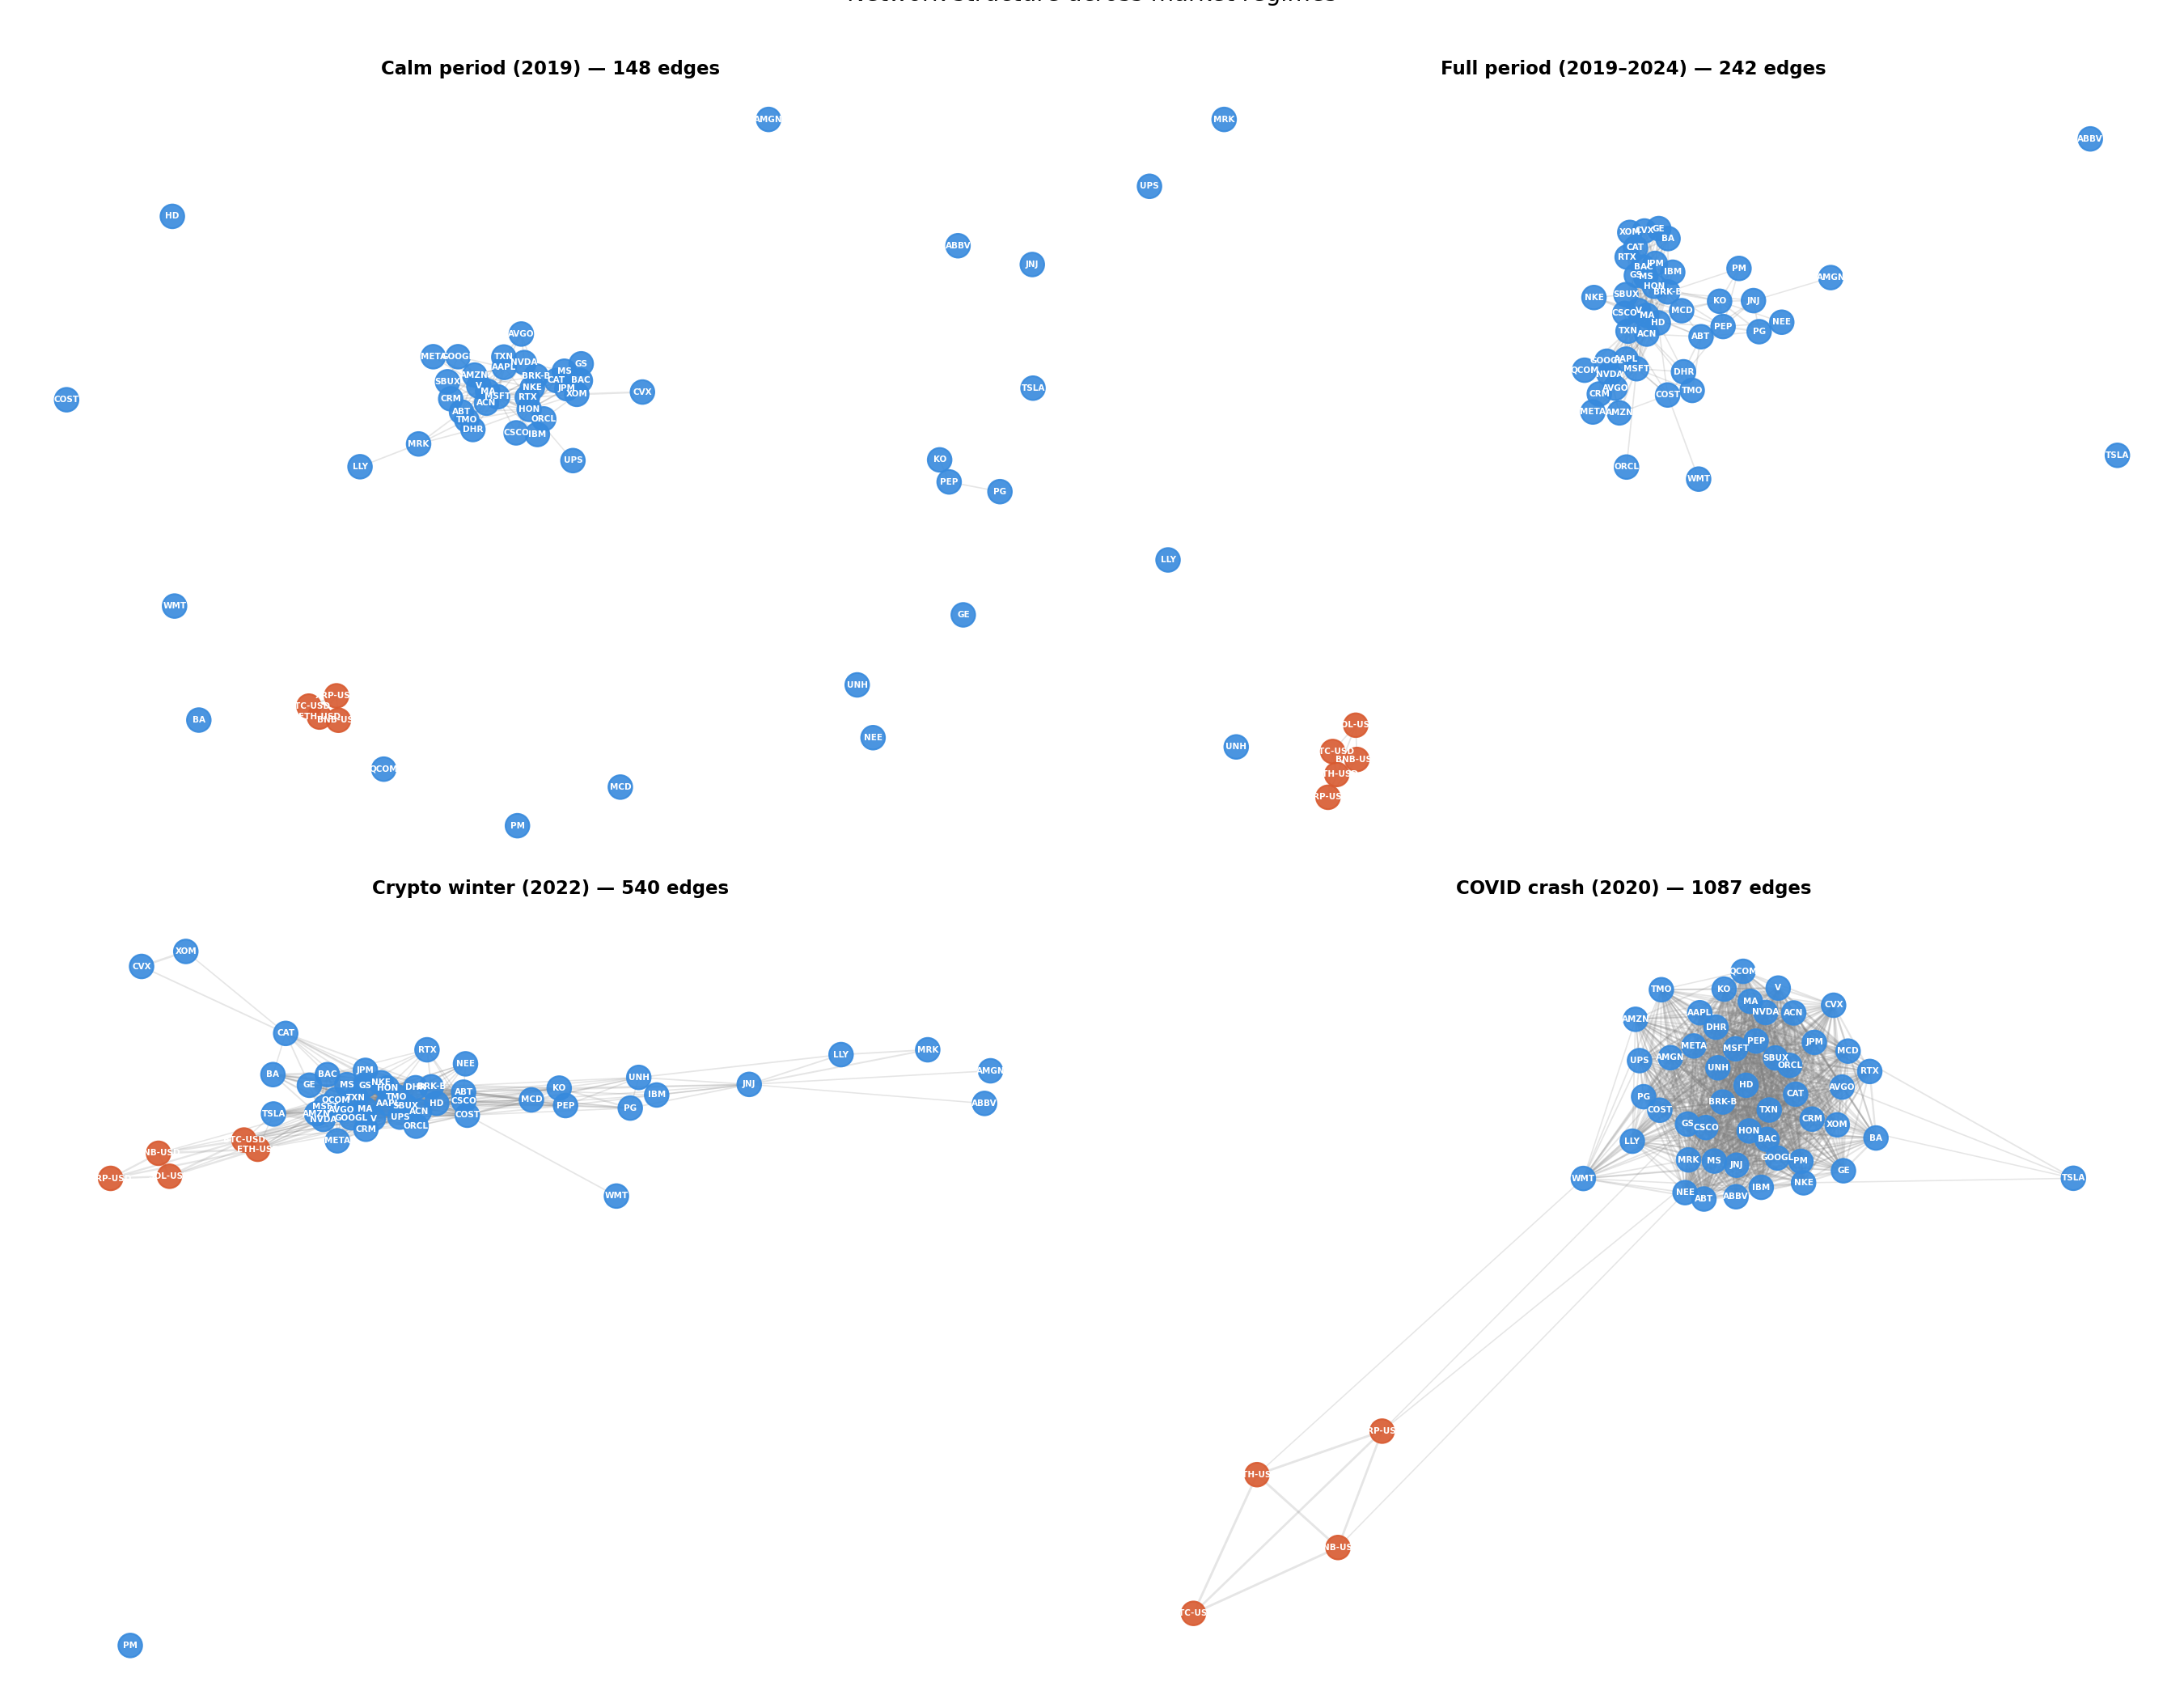

In [6]:
display(Image("crisis_network_comparison.png"))

## 7. Trading Strategy

**Signal logic:**
- Every 5 trading days, build the network on a rolling 60-day window
- Compute betweenness centrality for each stock
- **Long** the 10 lowest betweenness stocks — peripheral, idiosyncratic, 
  insulated from contagion
- **Short** the 10 highest betweenness stocks — hubs, overcrowded, 
  first to be hit in a crisis
- Crypto excluded from signal construction

This is a market-neutral strategy — the long and short legs partially cancel 
out broad market moves, making the strategy resilient to systemic shocks.
The key insight: **we are not predicting prices. We are predicting which 
stocks are structurally vulnerable based on their position in the network.**

## 8. Backtest Results

The equity curve tells a nuanced story. The strategy spends the first 3 years 
(2020–2022) oscillating around 1.0 — barely profitable, with two notable dips 
below 0.9 around 2020–2021. Then from 2023 onwards it rallies steadily, 
peaking at 1.30 in mid-2024 before giving back some gains.

The drawdown chart confirms the two difficult stretches: a prolonged trough 
from late 2020 through 2022, reaching nearly -20% at its worst. Notably, 
the strategy recovered completely from both drawdowns without permanent 
capital impairment — a sign that the signal is real even if slow to compound.

  STRATEGY PERFORMANCE SUMMARY
  Mean weekly return : 0.0004 (1.8% annualized)
  Weekly volatility  : 0.0119  (8.6% annualized)
  Annualized Sharpe  : 0.213
  Max drawdown       : -19.8%
  Total return       : 16.1%


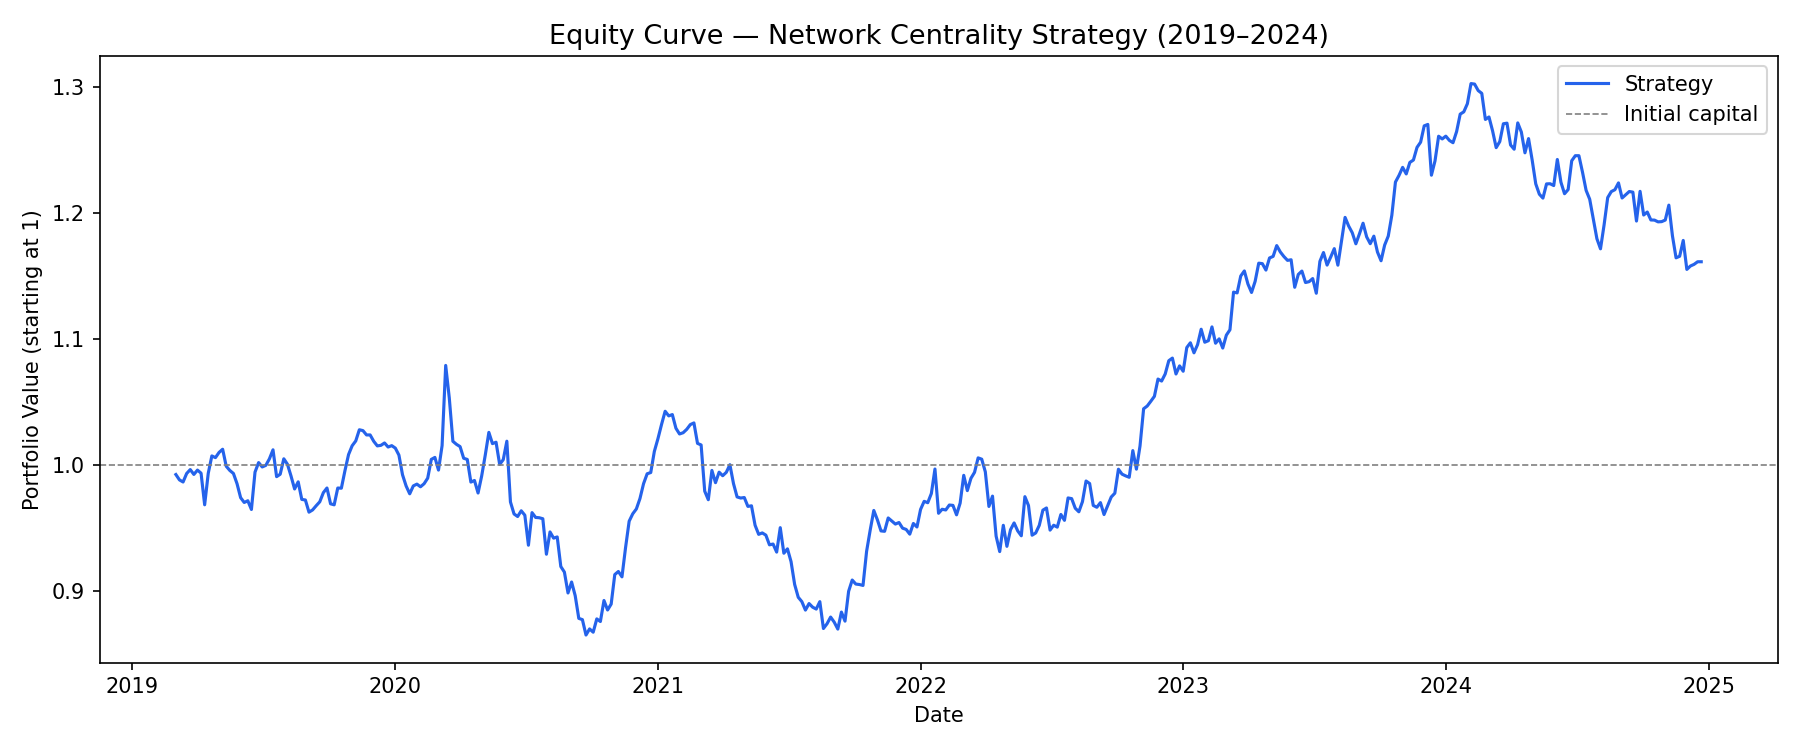

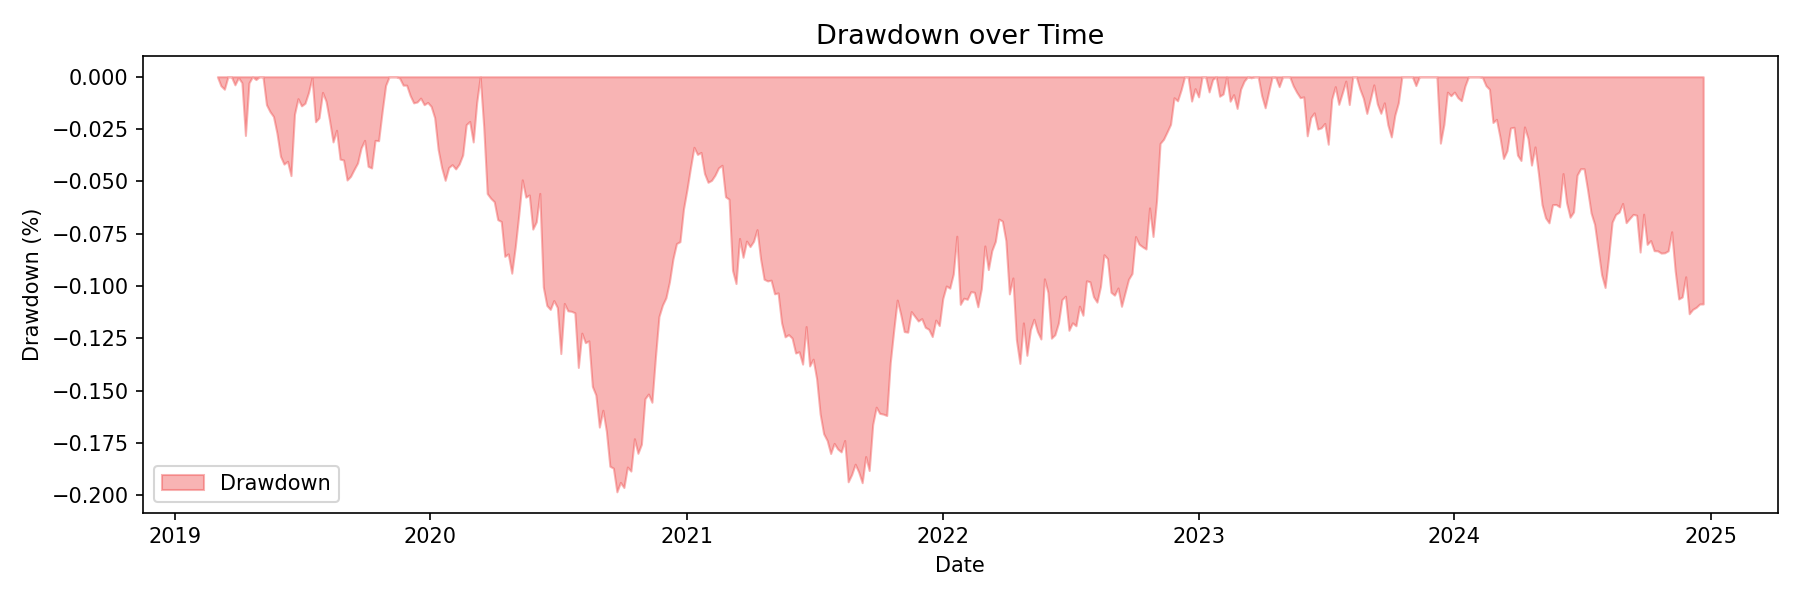

In [7]:
import numpy as np
import pandas as pd

results = pd.read_csv("data/results.csv", index_col=0, parse_dates=True)

weekly_mean = results["strategy"].mean()
weekly_std  = results["strategy"].std()
sharpe = (weekly_mean / weekly_std) * np.sqrt(52)
equity_curve = np.exp(results["strategy"].cumsum())
rolling_max  = equity_curve.cummax()
drawdown     = (equity_curve - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print("=" * 40)
print("  STRATEGY PERFORMANCE SUMMARY")
print("=" * 40)
print(f"  Mean weekly return : {weekly_mean:.4f} ({weekly_mean*52*100:.1f}% annualized)")
print(f"  Weekly volatility  : {weekly_std:.4f}  ({weekly_std*np.sqrt(52)*100:.1f}% annualized)")
print(f"  Annualized Sharpe  : {sharpe:.3f}")
print(f"  Max drawdown       : {max_drawdown*100:.1f}%")
print(f"  Total return       : {(equity_curve.iloc[-1]-1)*100:.1f}%")
print("=" * 40)

display(Image("equity_curve.png"))
display(Image("drawdown.png"))

## 9. Benchmark Comparison — Full Period

Against the S&P 500, the strategy looks weak on raw returns — 16.1% vs 187.7% 
over 6 years. But this comparison misses the point entirely.

The S&P 500 returned 187.7% over one of the greatest bull markets in history, 
driven by FAANG dominance and post-COVID stimulus. Any long-only strategy 
would have captured this. The network strategy is not long-only — it is 
market-neutral, meaning it does not benefit from a rising tide.

What it does offer: **half the drawdown** (-19.8% vs -39.1%) and **half the 
volatility** (8.6% vs 18.4%). A portfolio manager would overlay this strategy 
on top of long-only exposure to reduce tail risk, not use it as a replacement.

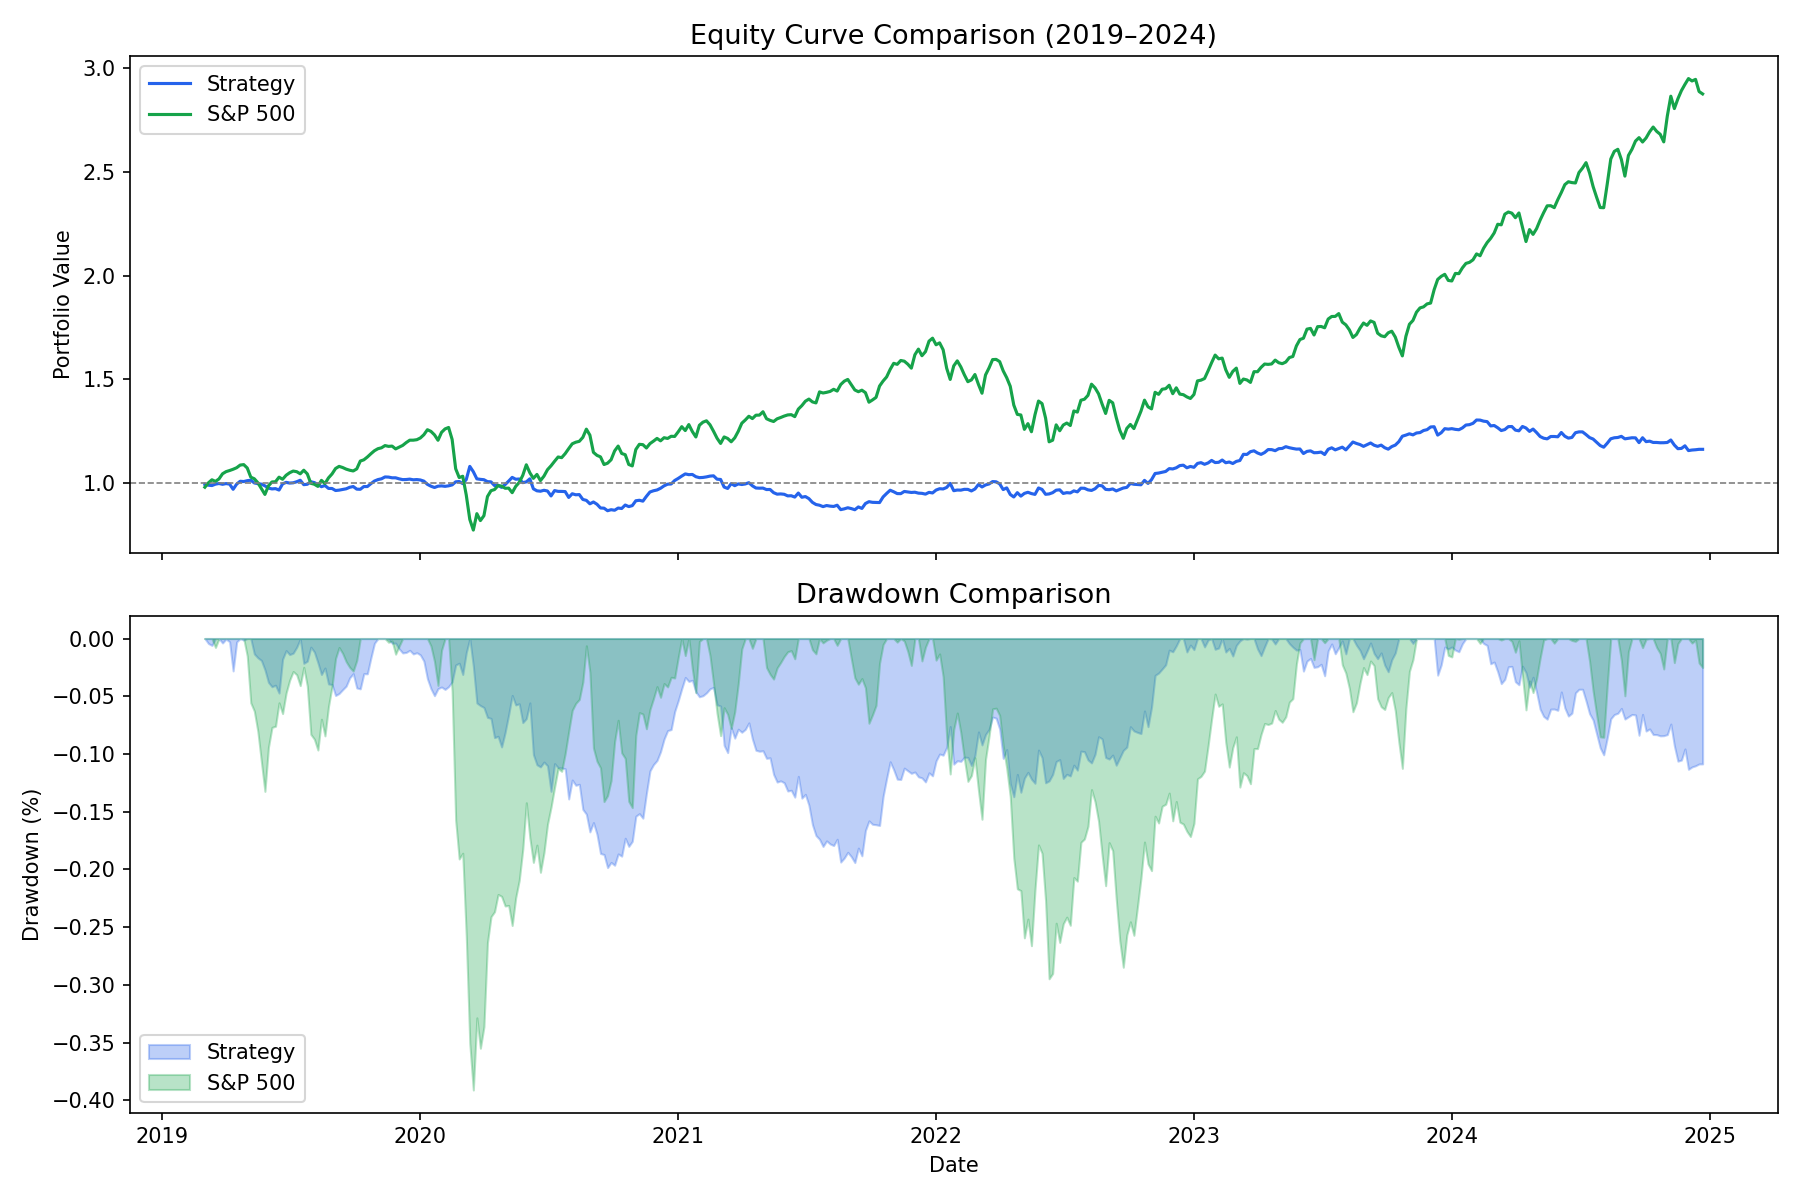

In [8]:
display(Image("benchmark_comparison.png"))

| Metric | Strategy | S&P 500 |
|--------|----------|---------|
| Ann. return | 1.8% | 12.9% |
| Ann. volatility | 8.6% | 18.4% |
| Sharpe | 0.213 | 0.704 |
| Max drawdown | -19.8% | -39.1% |
| Total return | 16.1% | 187.7% |

## 10. Crisis Behavior

This is where the strategy's value proposition is clearest.

**COVID crash (H1 2020):** The S&P dropped to 0.65 at its worst — a -35% 
drawdown in a matter of weeks. The strategy barely moved, staying within 
a few percent of 1.0 throughout. The blue drawdown area is almost invisible 
against the deep green of the S&P's collapse. The market-neutral construction 
absorbed the systemic shock almost entirely.

**Rate hike selloff (2022):** Even more striking. The S&P lost ~25% peak to 
trough over the full year. The strategy not only avoided the losses — it 
generated +13.5% over the same period. As rising rates compressed valuations 
uniformly, hub stocks (our short leg) were hit harder than peripheral stocks 
(our long leg), and the spread widened in our favor throughout the year.

| Crisis | Strategy | S&P 500 |
|--------|----------|---------|
| COVID Crash (H1 2020) | -5.4% | -12.0% |
| Rate Hike Selloff (2022) | +13.5% | -17.1% |

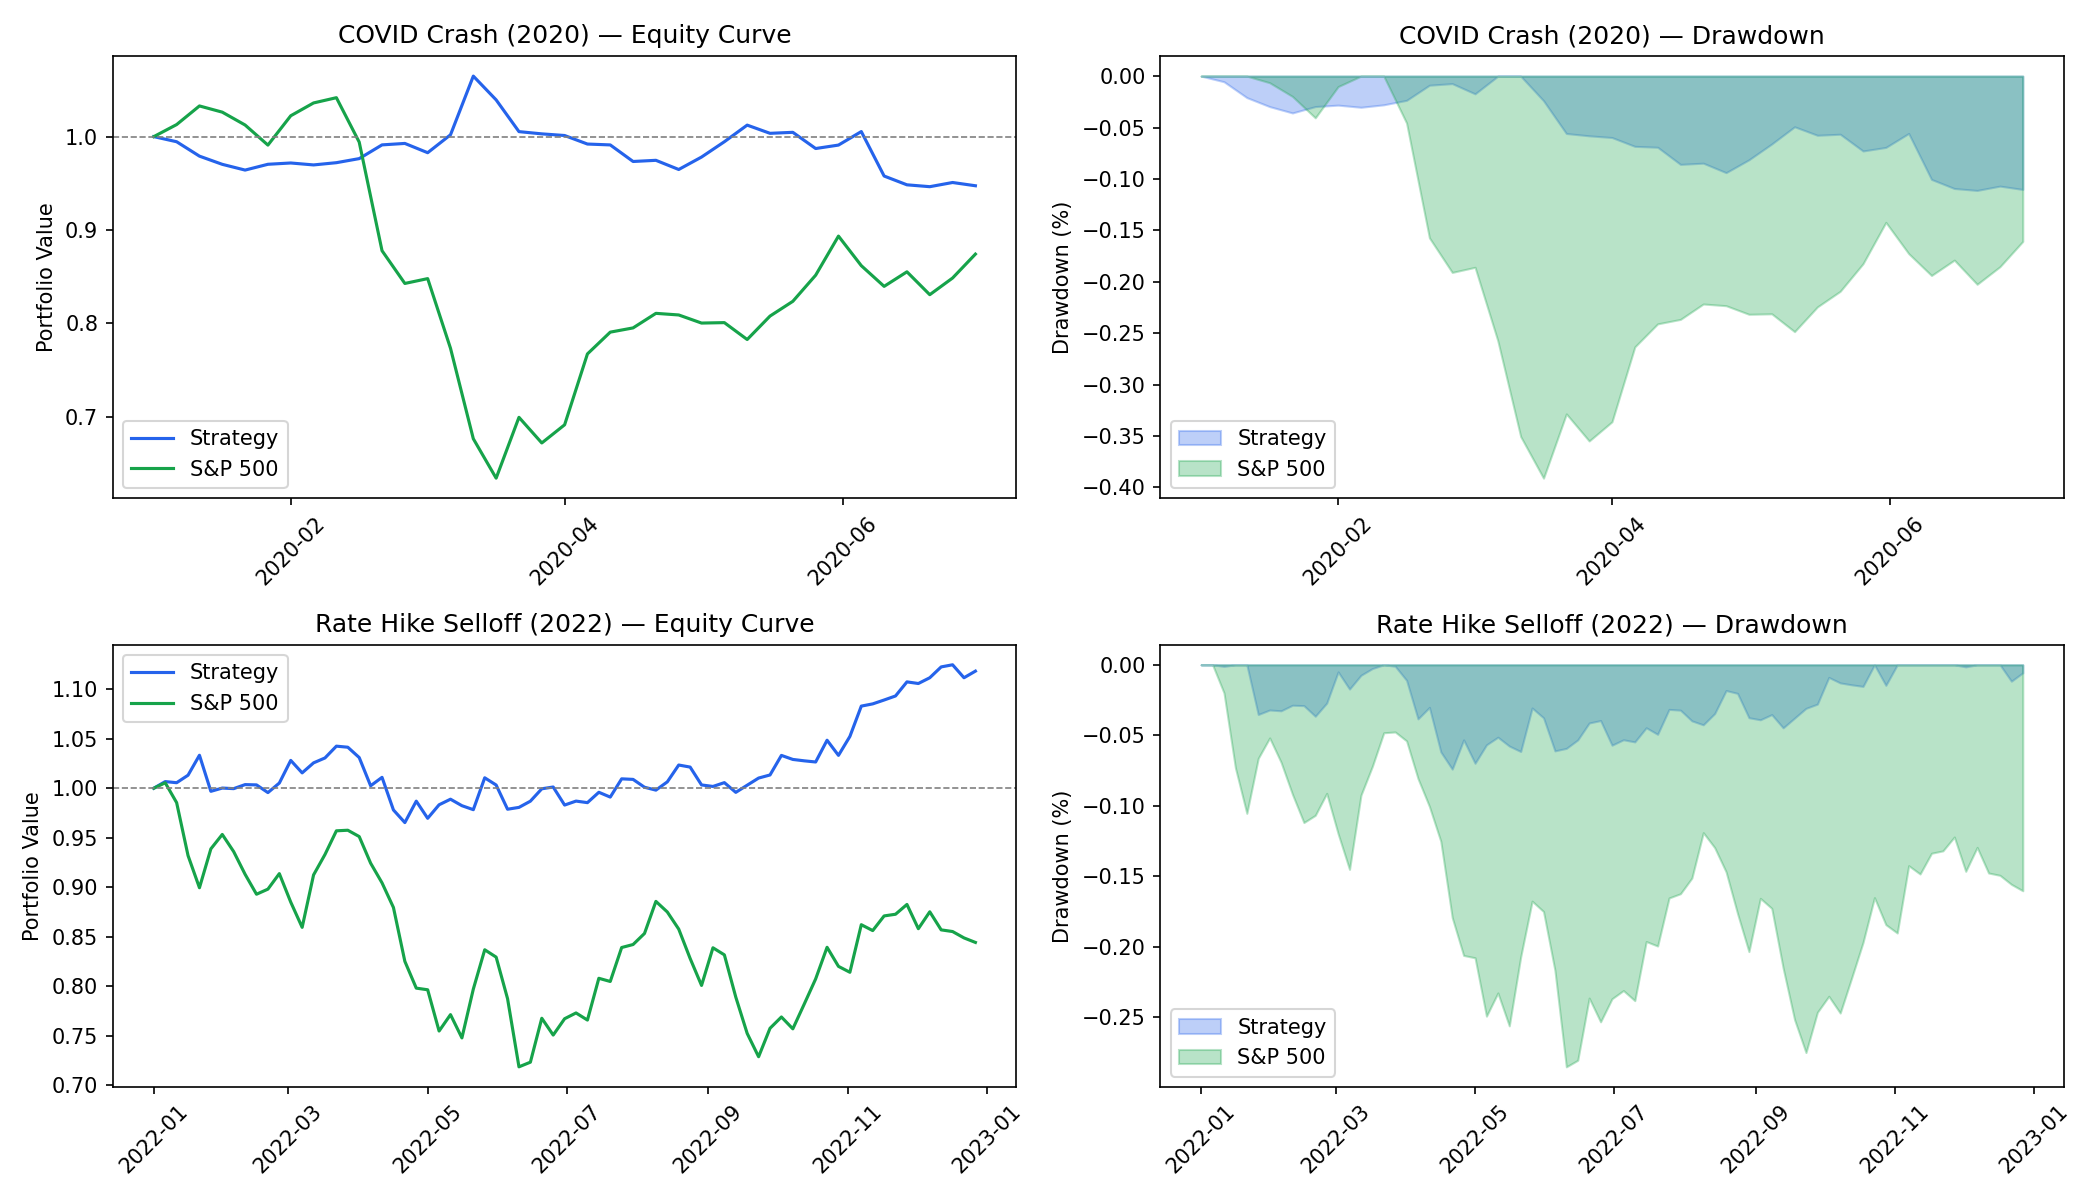

In [9]:
display(Image("crisis_analysis.png"))

## 11. Conclusion

A simple betweenness centrality signal, applied consistently over 6 years, 
produces a strategy with meaningful crisis-resilience properties:

- **Half the drawdown** of the S&P during two major market dislocations
- **Positive returns** during the 2022 rate hike selloff while the market lost 17%
- **Weak but positive Sharpe** (0.213) across all market conditions — 
  the signal is real, just modest

The weak performance during 2020–2022 is not a failure of the signal — it 
reflects a period where the market-neutral construction worked against the 
strategy during a powerful recovery rally. This is the inherent tradeoff: 
you give up bull market upside in exchange for crisis protection.

The natural next step is combining this signal with complementary factors — 
momentum, value, or volatility — to improve the Sharpe while retaining the 
crisis-resilience property. The network topology signal would serve as the 
**risk management layer** of a broader multi-factor strategy.